# 2장 1강: 시계열 데이터의 이해와 정상성 진단

## 실습 목표

이번 실습에서는 **Bike Sharing Demand** 데이터를 이용해 시간에 따른 자전거 대여량 변화를 확인합니다.

- 시계열 데이터에서 **시간 순서가 중요한 이유**를 확인합니다.
- 선 그래프와 시계열 분해를 이용해 **Trend / Seasonality / Residual**을 확인합니다.
- 이동평균을 이용해 데이터의 평균적인 수준 변화를 살펴봅니다.
- **ADF Test**를 이용해 정상성을 진단합니다.
- 정상성을 만족하지 않는 경우 **1차 차분**을 적용하고 ADF Test를 다시 수행합니다.

> 이 실습에서는 교안에서 다룬 내용만 사용합니다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- statsmodels
- 데이터: `Bike_Sharing_Demand.csv`

### 주요 컬럼

| 컬럼 | 의미 |
|---|---|
| `datetime` | 자전거 대여 기록 시각 |
| `casual` | 비등록 사용자의 대여 수 |
| `registered` | 등록 사용자의 대여 수 |
| `count` | 전체 자전거 대여 수 |

`count`는 `casual + registered`로 구성된 전체 대여량입니다.

## 실습 준비

먼저 데이터를 불러온 뒤 다음 내용을 확인합니다.

1. 데이터 크기와 상위 행
2. 주요 컬럼의 자료형
3. 결측치
4. `datetime`을 날짜/시간 자료형으로 변환
5. 시간 순서대로 정렬
6. 일별·월별 대여량 데이터 준비

> 일별·월별 집계 코드는 이후 시계열 실습을 위한 **준비 코드**로 제공됩니다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
%config InlineBackend.figure_format = 'retina'

bike = pd.read_csv("Bike_Sharing_Demand.csv")

print("데이터 크기:", bike.shape)
display(bike.head())

print("\n[자료형]")
display(bike[["datetime", "casual", "registered", "count"]].dtypes.to_frame("dtype"))

print("\n[결측치]")
display(bike[["datetime", "casual", "registered", "count"]].isna().sum().to_frame("missing"))

데이터 크기: (10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1



[자료형]


,dtype
datetime,str
casual,int64
registered,int64
count,int64



[결측치]


,missing
datetime,0
casual,0
registered,0
count,0


In [2]:
# datetime 변환 및 시간 순서 정렬
bike["datetime"] = pd.to_datetime(bike["datetime"])
bike = bike.sort_values("datetime").reset_index(drop=True)

print("최초 시각:", bike["datetime"].min())
print("마지막 시각:", bike["datetime"].max())
display(bike.head())

최초 시각: 2011-01-01 00:00:00
마지막 시각: 2012-12-19 23:00:00


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [3]:
# 일별 시계열 준비
bike["date"] = bike["datetime"].dt.date

daily = (bike.groupby("date", as_index=False)[["count", "casual", "registered"]].sum())

daily["date"] = pd.to_datetime(daily["date"])

# 월별 시계열 준비
bike["month"] = bike["datetime"].dt.to_period("M").astype(str)

monthly = (bike.groupby("month", as_index=False)["count"].sum())

monthly["month"] = pd.to_datetime(monthly["month"])

print("[일별 데이터]")
display(daily.head())

print("\n[월별 데이터]")
display(monthly.head())

[일별 데이터]


,date,count,casual,registered
0,2011-01-01,985,331,654
1,2011-01-02,801,131,670
2,2011-01-03,1349,120,1229
3,2011-01-04,1562,108,1454
4,2011-01-05,1600,82,1518



[월별 데이터]


,month,count
0,2011-01-01,23552
1,2011-02-01,32844
2,2011-03-01,38735
3,2011-04-01,50517
4,2011-05-01,79713


In [4]:
# 모든 날짜 존재여부 파악

min_date = bike['date'].min()
max_date = bike['date'].max()
all_hour = pd.date_range(start=min_date, end=max_date, freq='D')
missing_hours = all_hour.difference(bike['date'])

print('전체 기간 :', min_date, '~', max_date)
print('누락된 날짜 개수 :', len(missing_hours))
print('누락된 날짜 :')
print(missing_hours)

전체 기간 : 2011-01-01 ~ 2012-12-19
누락된 날짜 개수 : 263
누락된 날짜 :
DatetimeIndex(['2011-01-20', '2011-01-21', '2011-01-22', '2011-01-23',
               '2011-01-24', '2011-01-25', '2011-01-26', '2011-01-27',
               '2011-01-28', '2011-01-29',
               ...
               '2012-11-21', '2012-11-22', '2012-11-23', '2012-11-24',
               '2012-11-25', '2012-11-26', '2012-11-27', '2012-11-28',
               '2012-11-29', '2012-11-30'],
              dtype='datetime64[s]', length=263, freq=None)


---

# 필수 1. 시간 흐름과 시계열 패턴 확인

## 배경

시계열 데이터는 값 자체뿐만 아니라 **언제 관측되었는지와 어떤 순서로 나타났는지**가 중요합니다.

Bike Sharing Demand 데이터의 전체 대여량 `count`를 시간 순서대로 확인하고, 월별 대여량을 **Trend / Seasonality / Residual**로 나누어 살펴봅니다.

## 문제 1. 일별 대여량을 시간 순서대로 확인하세요.

### 요구사항

1. `daily["date"]`를 x축, `daily["count"]`를 y축으로 선 그래프를 그립니다.
2. 그래프 제목을 `Daily Bike Rentals`로 설정합니다.
3. 시간의 흐름에 따라 대여량의 전반적인 수준이 어떻게 변화하는지 설명합니다.

### 확인 포인트

- 시계열 그래프에서는 시간 순서를 유지했는가?
- 단순히 개별 값만 보는 것이 아니라 전체적인 흐름을 확인했는가?

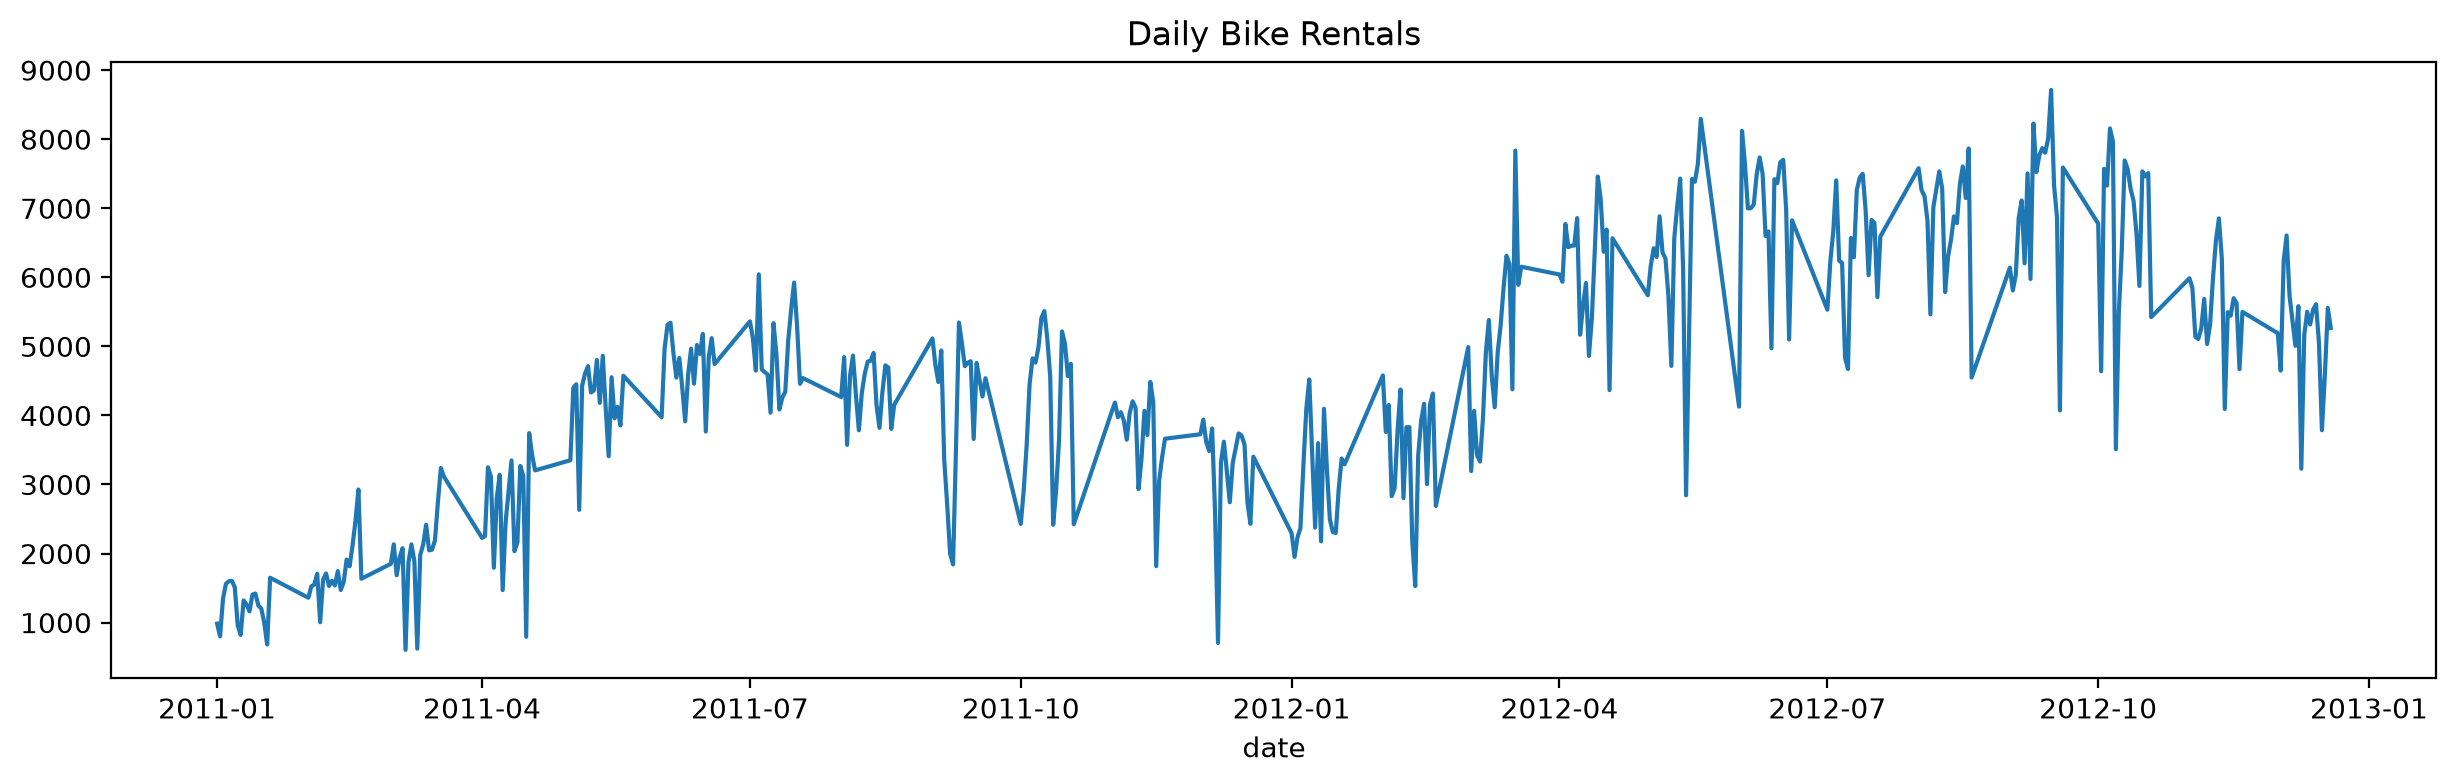

In [5]:
# TODO
# daily["date"]와 daily["count"]를 이용해 선 그래프를 그려보세요.

%config InlineBackend.figure_format = 'retina'

plt.figure(figsize=(15, 4))
plt.plot(daily['date'], daily['count'])

plt.xlabel('date')
plt.title('Daily Bike Rentals')

plt.show()

수준은 값이 대체로 어느 높이에서 움직이는지   
변동은 그 수준 주변에서 값이 얼마나 오르내리는지   
시계열에서 결측과 시간 누락은 다른 개념으로 반드시 시간 누락은 체크해야한다.

- 해석 : 관측된 일별 대여량은 2011년보다 2012년에 높은 수준을 보이며, 변동이 상승과 하락이 큰 편이며,
- 비교적 여름철에 상승하고 겨울철에 하강하는 모습을 보이지만 시간 누락이 있기 때문에 유의하여 해석해야한다.

---

##### Q1. 왜 `daily` 데이터를 무작위로 섞지 않고 날짜 순서대로 확인해야 할까요?

**답변:**  

- 시계열 데이터는 날짜 데이터이기 때문에 시간의 흐름에 따라 분석을 하고자 한다.
- 시계열 데이터를 무작위로 섞게 되면 날짜 순서대로 정렬이 되지 않기 때문에 흐름을 파악하기 어렵다.
- 시계열 데이터에서는 값이 나타난 순서 자체가 정보
- 날짜 순서가 엉망이면 어떤 값이 언제 발생했고, 나중에 발생했고, 증가나 감소 흐름을 명확하게 파악하기는 어렵다.

## 문제 2. 월별 대여량을 시계열 분해하세요.

### 요구사항

1. `monthly`의 `month`를 인덱스로 설정합니다.
2. `seasonal_decompose()`를 사용합니다.
3. `model="additive"`를 사용합니다.
4. 월별 데이터의 1년 반복 주기를 확인하기 위해 `period=12`를 사용합니다.
5. 결과에서 `Observed`, `Trend`, `Seasonal`, `Residual`을 확인합니다.

### 확인 포인트

- `period=12`의 의미를 이해했는가?
- Trend / Seasonality / Residual을 구분할 수 있는가?

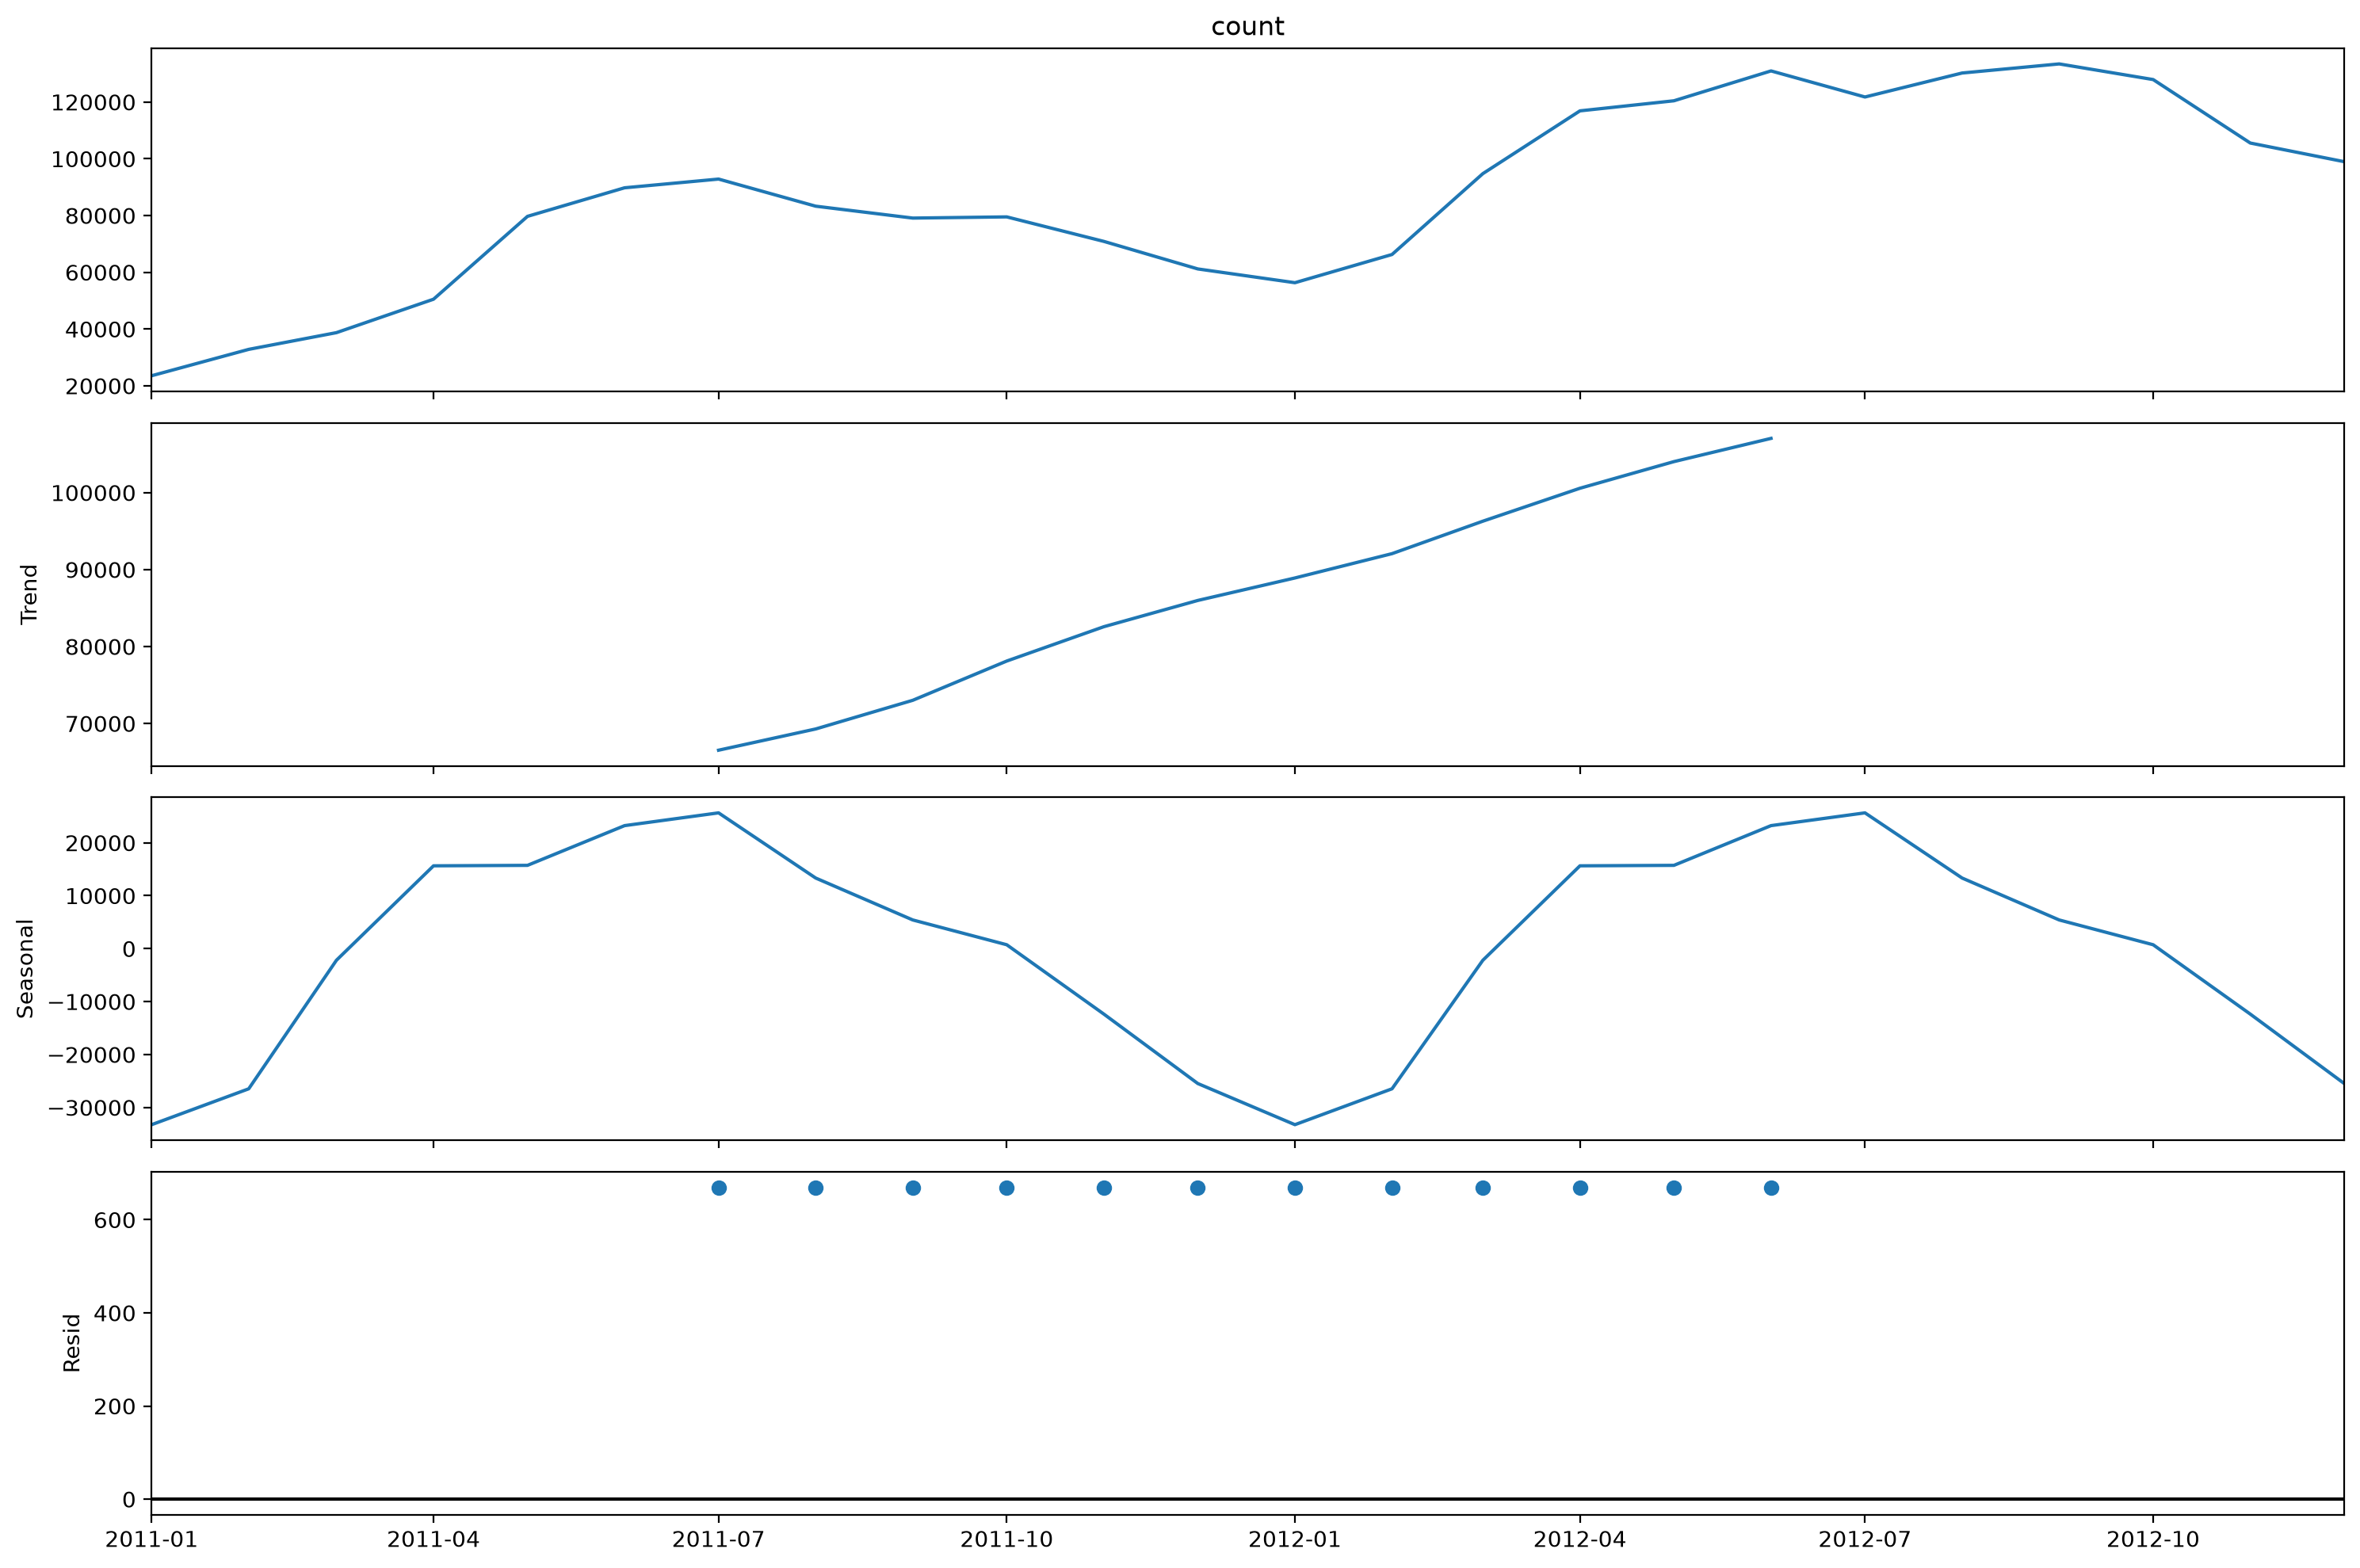

In [6]:
# TODO
# seasonal_decompose()를 이용해 월별 count를 분해해보세요.

monthly_df = monthly.set_index('month')

decomposition_12 = seasonal_decompose(
    monthly_df['count'],
    model='additive',
    period=12
)

fig = decomposition_12.plot()

fig.set_size_inches(15, 10)

plt.tight_layout()
plt.show()

- Trend : 여러 달(여기서는 month)에 걸친 장기 수준 변화(경사 확인)
- Seasonal : 12개월 위치에 따라 반복하도록 추정된 편차(추세보다 강해지거나 약해지는 달이 있는지)
- Residual : 추세와 계절 성분을 빼고 남은 값(추세와 계절성으로 설명되지 않은 남은 값)

---

### Q2. 다음 설명을 각각 Trend / Seasonality / Residual과 연결하세요.

- 시간이 지나면서 나타나는 장기적인 증가 또는 감소
    - Trend
    - 우상향(대체로 상승), 경사가 비교적 완만하게 상승 중이다.

- 일정한 시간 간격을 두고 반복되는 변화
    - Seasonality
    - 봄부터 여름까지 상승, 가을, 겨울은 하강하는 추세

- 추세와 계절
    - 잔차의 값이 양수이면 추세와 계절성에 비해 실제 관측값이 큰 편, 음수라면 작은편
    - 주의할 점은 미래 데이터를 예측한 오차를 의미하는 잔차의 의미는 아니다.


> 해석 :    
> 월별 관측 합계를 분해한 결과,    
> 가운데 구간(봄, 여름)에서 상승하는 추세와    
> 연말(가을, 겨울)에 낮아지는 계절 성분이 나타났고, 추세가 우상향하는 형태로 보인다.  
> 잔차는 거의 일정해보이지만 시간 누락과 기간을 고려하여 계산하여야 한다.

---

# 필수 2. 정상성 진단과 1차 차분

## 배경

정상성은 시간이 지나도 시계열의 **평균적인 수준과 변동의 특성이 크게 달라지지 않는 성질**입니다.

이번 문제에서는 일별 전체 대여량 `count`의 이동평균을 확인하고, ADF Test를 이용해 정상성을 판단합니다. 정상성을 만족한다고 보기 어렵다면 1차 차분을 수행한 뒤 다시 ADF Test를 진행합니다.

## 문제 1. 이동평균으로 평균 수준의 변화를 확인하세요.

### 요구사항

1. `daily["count"]`의 최근 7개 값 이동평균을 계산하여 `rolling_mean` 컬럼에 저장합니다.
2. 원본 `count`와 `rolling_mean`을 같은 그래프에 나타냅니다.
3. 이동평균이 시간에 따라 변하는지 확인합니다.

### 확인 포인트

- `rolling(window=7).mean()`을 사용했는가?
- 이동평균이 개별 값의 작은 변동을 줄여 전체 수준을 보기 위한 방법임을 이해했는가?

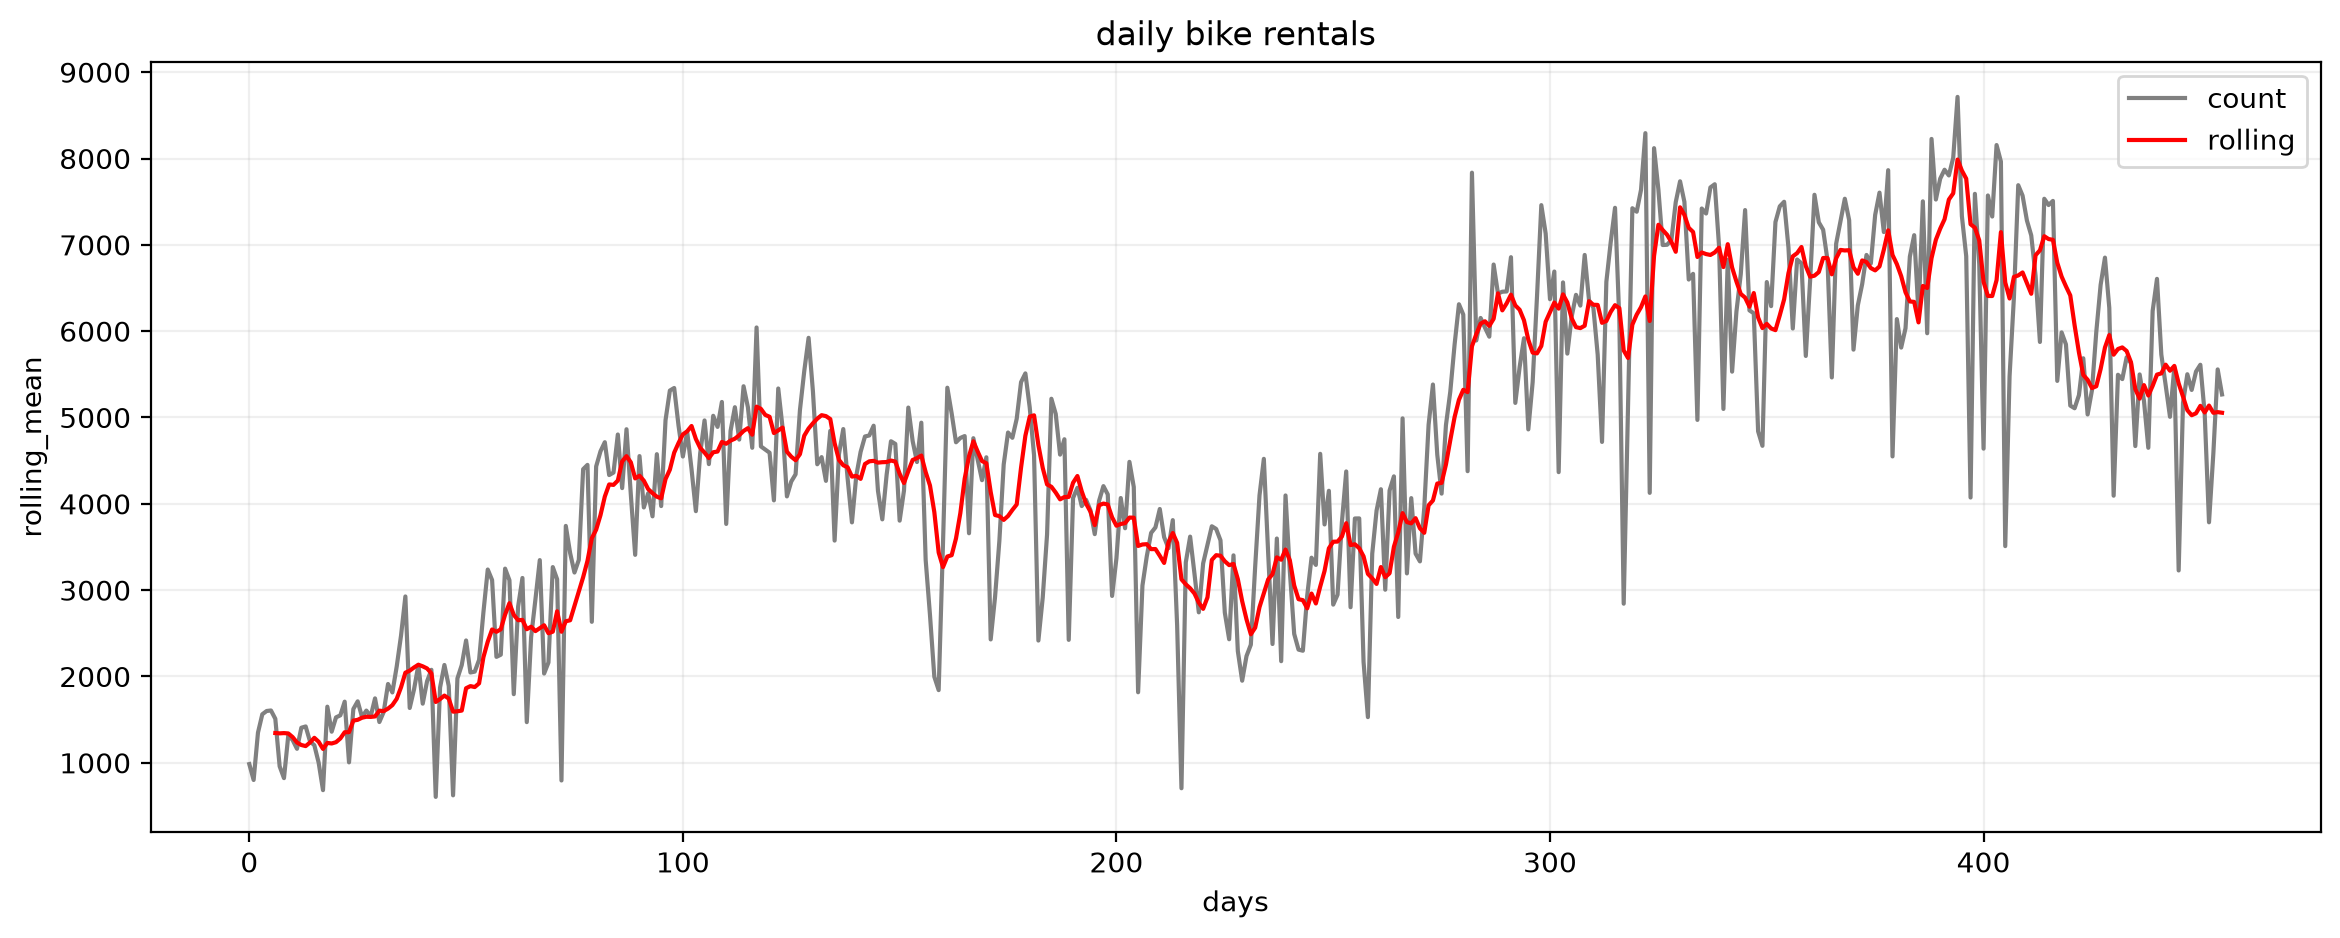

In [7]:
# TODO
# 7개 값 이동평균을 계산하고 원본 count와 함께 시각화하세요.

daily['rolling_mean'] = daily['count'].rolling(window=7).mean()

plt.figure(figsize=(14, 5))

# 원 데이터
plt.plot(daily.index, daily['count'], label = 'count', color='gray')
plt.plot(daily.index, daily['rolling_mean'], label='rolling', color='red')

plt.title('daily bike rentals')
plt.xlabel('days')
plt.ylabel('rolling_mean')
plt.legend()
plt.grid(alpha=0.2)

- 이동평균 : 단기 변동을 완화하여 보겠다.
    - 시계열 보간 방법 중 하나 (선형보간)
    - 여름철 기온

- 정상성 : 값이 움직이는 중심이 시간에 따라 다르게 나타나는 지?
    - -> 이동평균을 통해서 정상성의 가능성을 확인하고자 함

- 7일 평균 : rollling(이동평균), window=7이면 최근 7개의 행을 의미함. 7일을 의미하지 않음 

> **해석** :   
> 최근 7개의 관측값의 평균은 변동폭이 심한 원본 데이터의 변동을 완화했지만 야전히 변동폭의 여파는 남아있다.   
> 평균 수준이 일정하지 않음을 확인했기 때문에 정상성을 판단하기에는 추가적인 확인이 필요하다(ADF)

## 문제 2. 원본 일별 대여량에 ADF Test를 수행하세요.

### 요구사항

1. `adfuller()`를 이용해 `daily["count"]`를 검정합니다.
2. ADF Statistic과 p-value를 출력합니다.
3. 유의수준 0.05를 기준으로 정상성을 판단합니다.

### 판단 기준

- `p-value < 0.05` → 귀무가설 기각 → 정상성을 만족한다고 판단
- `p-value ≥ 0.05` → 귀무가설을 기각하지 못함 → 정상성을 만족한다고 보기 어려움

In [8]:
# TODO
# 원본 daily["count"]에 ADF Test를 수행하세요.
from statsmodels.tsa.stattools import adfuller

statis, pvalue, *_ = adfuller(daily['count'], result_object=False)

print(f'ADF Statistic : {statis:.4f}')
print(f'ADF p-value : {pvalue:.4f}')

if pvalue <= 0.05:
    print('귀무가설 기각 | 정상성을 만족합니다.')
else:
    print('귀무가설 기각하지 못함 | 정상성을 만족한다고 보기 어렵습니다.')

ADF Statistic : -2.0025
ADF p-value : 0.2855
귀무가설 기각하지 못함 | 정상성을 만족한다고 보기 어렵습니다.


- 귀무가설 : 시계열에 단위근이 존재한다.
- 대립가설 : 시계열에 단위근이 존재하지 않는다.

---

### Q3. 원본 데이터의 p-value를 기준으로 정상성을 어떻게 판단할 수 있나요?

**답변:**  

- ADF의 -2.00의 의미: 단위근 가설에 대한 증거를 요약한 검정 통계량
- p-value 0.28의 의미 : 단위근 귀무가설 아래 현재 검정 통계량 또는 기각 방향으로 더 극단적 통계량 확인

> **해석** :    
> 원본 전체 대여량의 ADF 통계량은 약 -2, p-value는 약 0.28,   
> 유의수준인 0.05보다 높기 때문에 단위근 귀무가설을 기각하지 못함.   
> 그래서 앞서 이동평균과 함께 1차 차분을 검토해야함,    
> 단 날짜 누락으로 인한 한계점은 뚜렷하게 보임.

## 문제 3. 1차 차분 후 정상성을 다시 확인하세요.

### 요구사항

1. `.diff()`를 이용해 `daily["count"]`를 1차 차분합니다.
2. 첫 번째 `NaN`은 `dropna()`로 제거합니다.
3. 차분된 값을 선 그래프로 나타냅니다.
4. 차분 데이터에 ADF Test를 다시 수행합니다.
5. 차분 전과 차분 후 p-value를 비교하여 정상성 변화를 설명합니다.

### 확인 포인트

- 차분값이 `현재 값 - 이전 값`이라는 것을 이해했는가?
- 차분 후 데이터의 의미가 **일별 대여량 → 이적 관측일 대비 대여량 변화**로 달라짐을 이해했는가?
- 차분 후 ADF Test를 다시 수행했는가?

[1차 차분]


,date,count_diff
0,2011-01-01,NaN
1,2011-01-02,-184.0
2,2011-01-03,548.0
3,2011-01-04,213.0
4,2011-01-05,38.0



[차분 비교]
차분 전 p-value : 0.2855
차분 전 : 비정상 시계열

차분 후 p-value : 0.0000
차분 후 : 정상 시계열


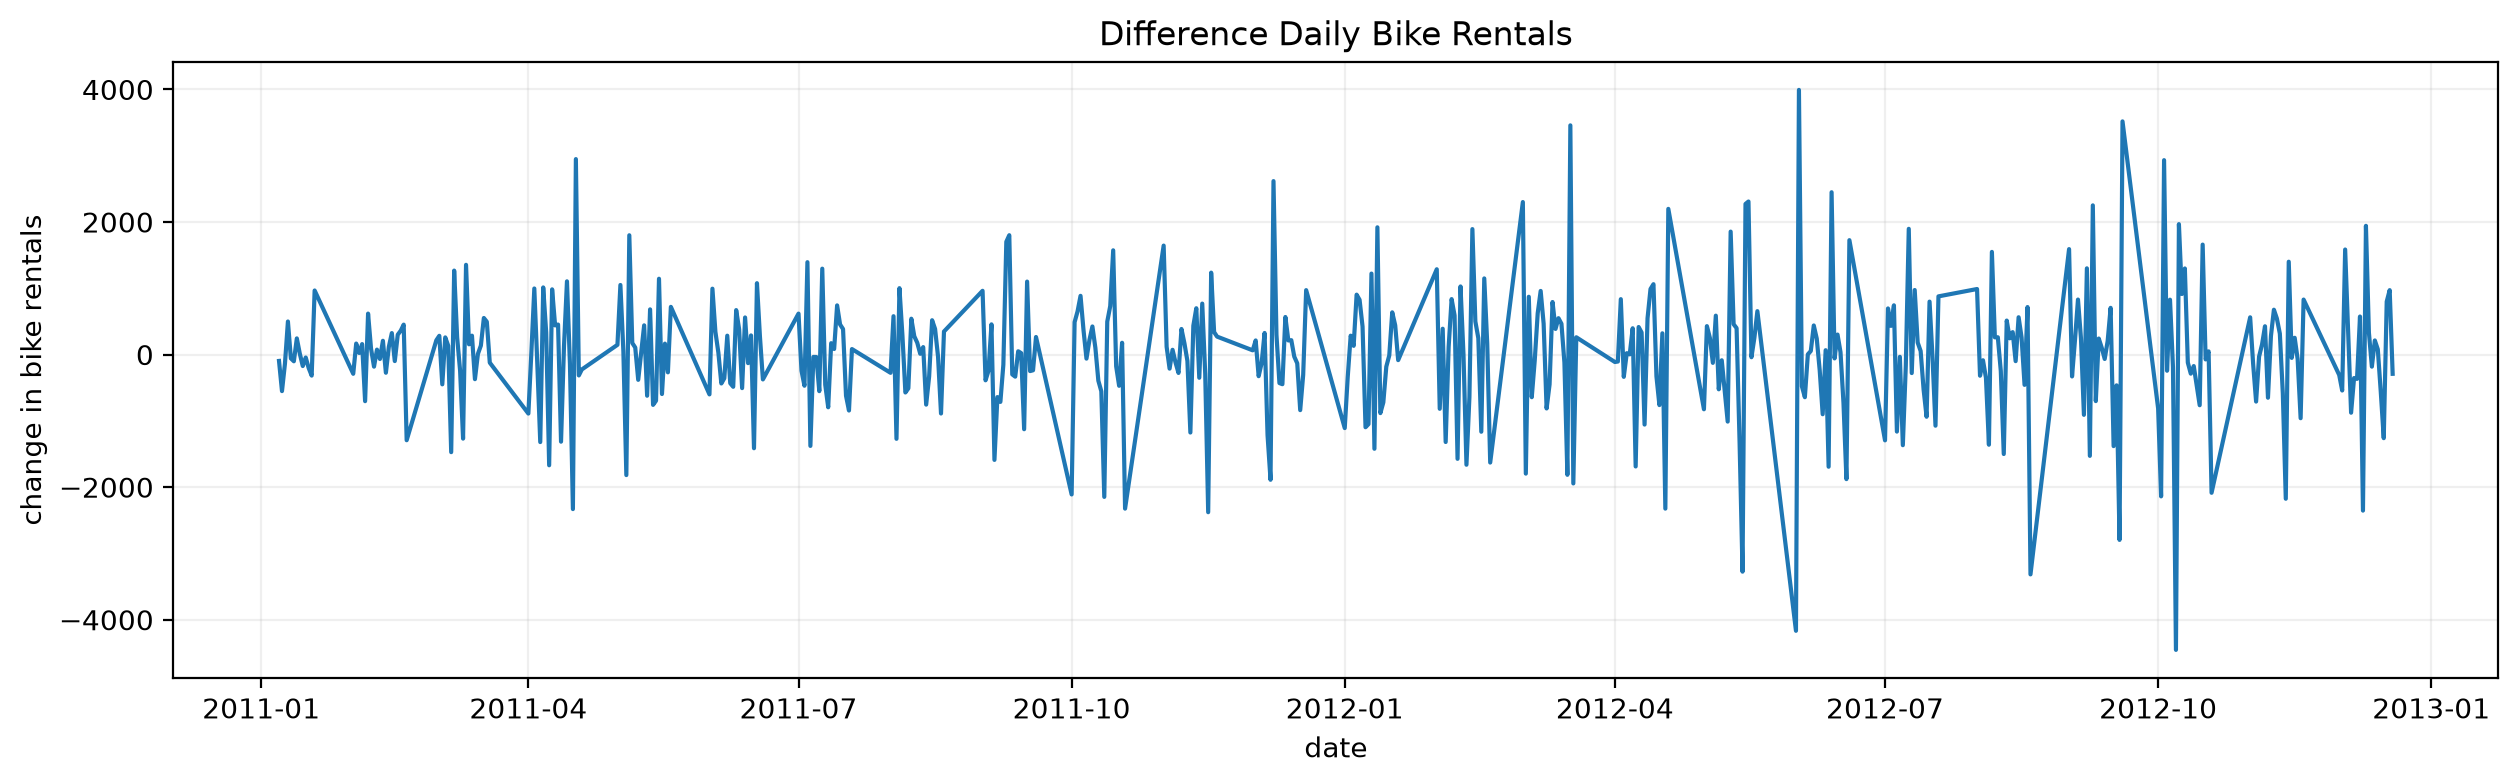

In [9]:
# TODO
# 1차 차분 → 시각화 → ADF Test 재실행 순서로 진행하세요.

# 1차 차분
daily['count_diff'] = daily['count'].diff()

print('[1차 차분]')
display(daily[['date', 'count_diff']].head())

# 시각화
daily_copy = daily.dropna()

plt.figure(figsize=(15, 4))
plt.plot(daily_copy['date'], daily_copy['count_diff'])

plt.title('Difference Daily Bike Rentals')
plt.xlabel('date')
plt.ylabel('change in bike rentals')
plt.grid(alpha=0.2)

# ADF TEST
before_statis, before_pvalue, *__ = adfuller(daily['count'], result_object=False)
after_statis, after_pvalue, *__ = adfuller(daily_copy['count_diff'], result_object=False)


print('\n[차분 비교]')
print(f'차분 전 p-value : {before_pvalue:.4f}')

if before_pvalue < 0.05:
    print('차분 전 : 정상 시계열')
else:
    print('차분 전 : 비정상 시계열')


print(f'\n차분 후 p-value : {after_pvalue:.4f}')

if after_pvalue < 0.05:
    print('차분 후 : 정상 시계열')
else:
    print('차분 후 : 비정상 시계열')

- 1차 차분 : t(현재 시간), t-1(관측 행 앞), 관측 행의 순서
    - 2011-01-01 현재 대여량 985, 이전 대여량 없음 -> 차분값 Nan
    - 2011-01-02 현재 대여량 801, 이전 대여량 985 -> 차분값 -184
    - 이전 관측일 보다 184건 감소했다.

- 원본 VS 차분 그래프 
    - 원본 그래프는 대여량 수준이 1000~9000건 사이에서 크게 움직임
    - 차분 그래프는 대여량 수준이 비교적 0에서 대체로 움직임
    - -> 차분은 그래프의 변동 폭이 일정한가?를 직관적으로 보기 위해 진행

- 차분 전후 검정 판단 비교
    - 원본 : p-value(0.28)여서 0.05보다 크기 때문에 귀무가설을 기각하지 못함
    - 1차 차분 : p-value(1.2e-21) 0.05보다 작기 때문에 귀무가설을 기각함

> 해석 :   
> 원본 시계열에서 p-value는 0.28로 귀문가설을 기각하지 못하였으나,   
> 1차 차분 후에는 1.2e-21로 귀무가설을 기각함.      
> 차분 그래프에서는 변화의 폭이 줄고 0 주변의 값이 나타남   
> 단, 여전히 큰 변동폭들이 남아있고, 누락 날짜가 있기 때문에 추가적으로 변동폭 확인이 필요함

### Q4. 차분 전과 차분 후 데이터의 의미는 어떻게 달라지나요?

**답변:**  

- 차분 전 `count` : 각 관측일에 기록된 전체 자전거 대여량 합계
- 차분 후 `count_diff` : 이전 관측일 대비 전체 자전거 대여량 합계의 증감

---

# 과제 1. 등록 사용자 대여량의 정상성 진단

## 배경

필수 2에서는 전체 대여량 `count`를 이용해 정상성 진단과 차분을 수행했습니다.

이번에는 같은 과정을 **등록 사용자 대여량 `registered`**에 직접 적용합니다.

> 과제는 필수 실습에서 연습한 방법을 동일하게 적용하는 수준입니다.

## 요구사항

1. `daily["registered"]`를 날짜 순서대로 선 그래프로 나타냅니다.
2. 최근 7개 값의 이동평균을 계산하여 원본 데이터와 함께 나타냅니다.
3. 원본 `registered`에 ADF Test를 수행합니다.
4. p-value를 기준으로 정상성을 판단합니다.
5. 정상성을 만족한다고 보기 어렵다면 1차 차분합니다.
6. 1차 차분을 수행한 경우, 차분 데이터에 ADF Test를 다시 수행합니다.
7. 원본과 차분 데이터의 p-value를 근거로 정상성 판단을 설명합니다. 차분하지 않았다면 그 이유를 설명합니다.
8. 진단 결과를 근거로 원본 데이터를 사용할지, 1차 차분한 데이터를 사용할지, 추가 진단이 필요한지 선택하고 이유를 설명합니다.

### 확인 포인트

- 원본 데이터의 시간 흐름을 확인했는가?
- 이동평균으로 평균 수준의 변화를 확인했는가?
- ADF Test의 p-value를 0.05와 비교했는가?
- 필요한 경우 1차 차분 후 ADF Test를 다시 수행했는가?
- 결과를 코드 출력값을 근거로 설명했는가?
- ADF 검정 결과와 그래프를 근거로 이후 모델링 방향을 선택했는가?


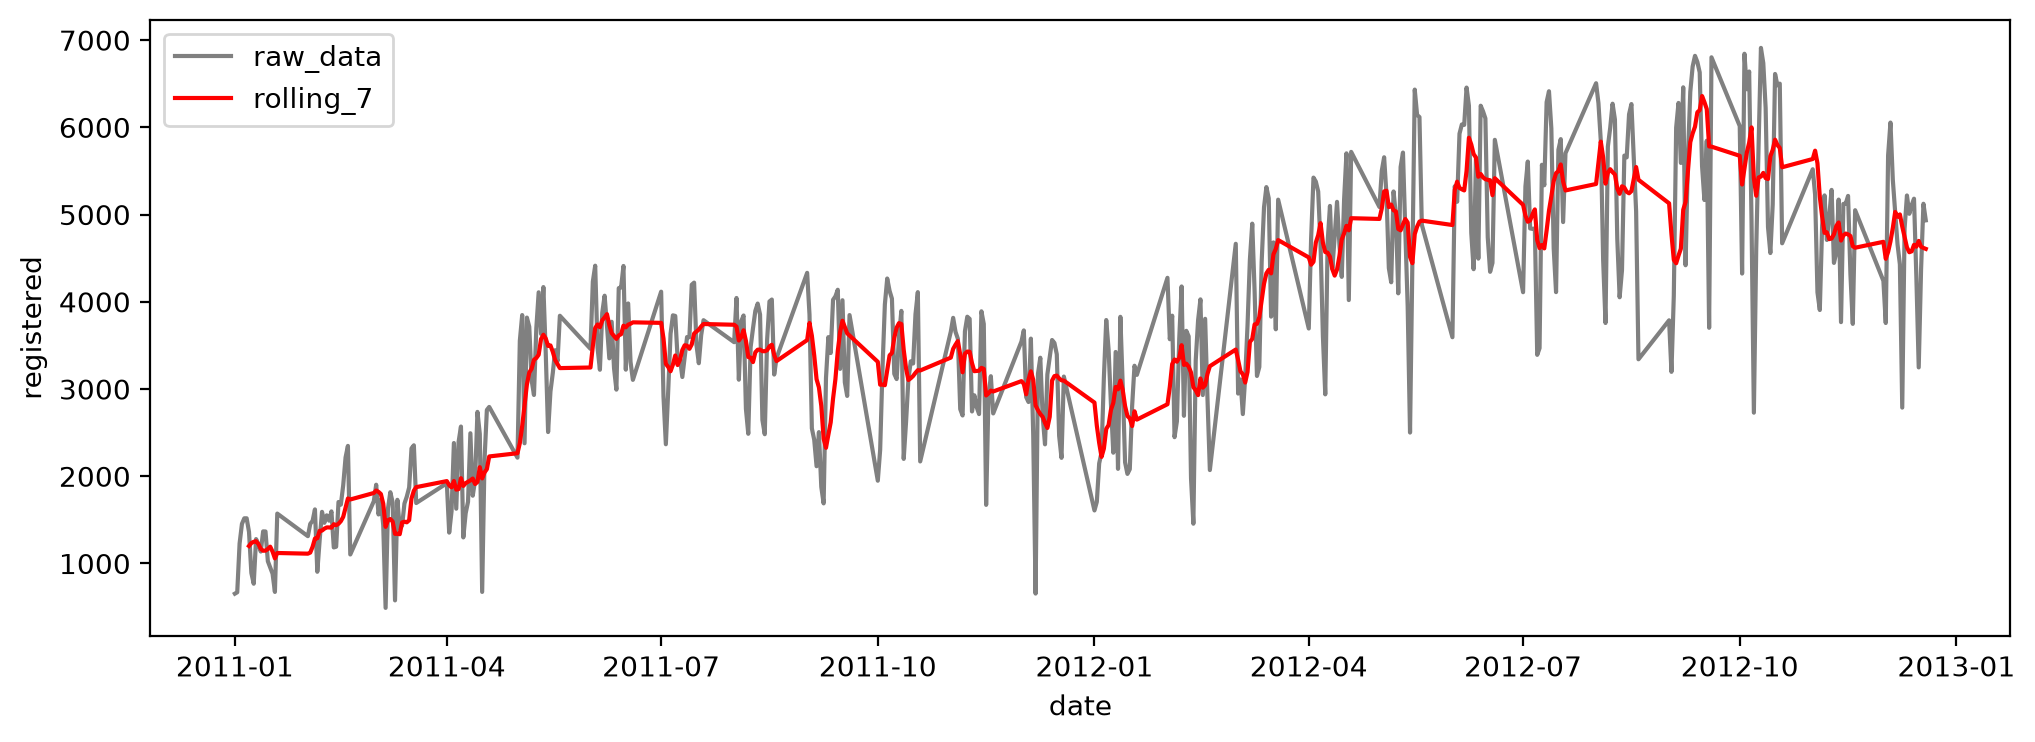

차분 전 ADF p-value : 0.3288
차분 전 : 비정상성 시계열

차분 후 ADF p-value : 0.3309
차분 후 : 비정상성 시계열


In [10]:
# TODO
# 시각화 → 최근 7개 값 이동평균 → 원본 ADF Test
# → 필요 시 1차 차분 및 ADF Test 재실행 → 결과 비교
# Q5·Q6에는 출력값과 그래프를 근거로 해석과 모델링 방향을 작성하세요.

daily = daily.sort_values('date')

daily['rolling_7'] = daily['registered'].rolling(window=7).mean()

plt.figure(figsize=(12, 4))

plt.plot(daily['date'], daily['registered'], color='gray', label='raw_data')
plt.plot(daily['date'], daily['rolling_7'], color='red', label='rolling_7')


plt.xlabel('date')
plt.ylabel('registered')
plt.legend()

plt.show()


# ADF
before_statis, before_pvalue, *__ = adfuller(daily['registered'], result_object=False)

if before_pvalue >= 0.05:
    print(f'차분 전 ADF p-value : {before_pvalue:.4f}')
    print('차분 전 : 비정상성 시계열')

    daily = daily.dropna(subset='rolling_7')
    after_statis, after_pvalue, *__ = adfuller(daily['rolling_7'], result_object=False)
    print(f'\n차분 후 ADF p-value : {after_pvalue:.4f}')

    if after_pvalue >= 0.05:
        print('차분 후 : 비정상성 시계열')
    else:
        print('차분 후 : 정상성 시계열')
else:
    print('차분 전: 정상성 시계열')



### Q5. 원본 등록 사용자 대여량의 ADF 검정 결과를 어떻게 해석할 수 있나요? 차분했다면 차분 전후 결과를 비교하고, 차분하지 않았다면 그 이유를 설명하세요.

**답변:**
- 원본의 ADF p-value는 0.3288로 0.05보다 커 정상성을 만족한다고 보기 어렵다고 나타났다.

- 따라서 차분을 진행하였다.
- 차분 후 ADF p-value는 0.3309로 0.05보다 커 차분 후에도 정상성을 만족하기 어렵다고 나타났다.

### Q6. 이후 시계열 모델링에서는 원본 데이터 사용, 1차 차분 데이터 사용, 추가 진단 중 어떤 방향을 선택하겠나요? ADF 검정 결과와 그래프를 근거로 설명하세요.

**답변:**
- ADF 검정 결과 차분 후에도 정상성을 만족하기 어렵다고 나타났으며,

- 그래프에서도 시간에 따른 추세와 변화가 보이므로 
- 이동평균의 값 증가와 같은 추가 진단 후 ADF 검정을 다시 수행하고 정상성을 파악한다. 


---

# 실습 마무리

아래 질문에 짧게 답해보세요.

1. 시계열 데이터에서 시간 순서가 중요한 이유는 무엇인가요?
2. Trend와 Seasonality의 차이는 무엇인가요?
3. ADF Test에서 `p-value ≥ 0.05`라면 어떻게 해석하나요?
4. 1차 차분은 어떤 값을 계산하나요?
5. 차분 후 ADF Test를 다시 수행해야 하는 이유는 무엇인가요?